In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.linalg import expm

### Luokkien määrittely

In [ ]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C #Varausenergia
        self.E_J=E_J #Josephsonin energia
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[2]-self.phi[1] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä
        M[0,-1]=1
        M[-1,0]=1
        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies #Ominaisenergiat
        self.eigenstates = eigenstates #Ominaistilat
        self.frequency = energies[1]-energies[0] #Kubitin taajuus
    
    def H_D_eigbasis(self,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0]) #Diagonaalimatriisi ominaisenergioista (lukumäärä ensimmäiset dim)

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(A): return H_0 + A*M

        return H_t
    
class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, A, dt): return expm(-1j * self.generator(A) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, A_vals, dt): #Floquet-operaattori

        U_f = self.U(0, 0) #Aikakehitysoperaattori yhdelle Floquet-jaksolle
        for A in A_vals: 
            U_f = self.U(A, dt) @ U_f
        return U_f

class Pulse:

    def __init__(self,frequency,f_supp,pulse_funcs,pulse_times,time_unit=1):

        #Tarkistetaan, että on annettu sama määrä pulssifunktiota ja -aikoja
        if len(pulse_times)!=len(pulse_funcs):
            raise Exception("Pulse function and time interval arrays must have the same size") 

        #Määritellään ajan arvot eri pulssin osille
        piecewise_time_vals=[(np.arange(time)*time_unit) for time in pulse_times]

        #Ajan arvot koko pulssin ajalle
        self.time_vals = np.arange(np.sum(pulse_times))*time_unit

        #Pulssin amplitudi määriteltynä kolmessa osassa
        piecewise_envelope_vals=[np.array([pulse_funcs[i](t) for t in piecewise_time_vals[i]]) for i in range(0,len(piecewise_time_vals))]

        #Pulssin amplitudi
        self.envelope = np.concatenate(piecewise_envelope_vals)

        #Derivaatta amplitudifunktiosta
        self.envelope_derivative = np.gradient(self.envelope,time_unit)
        
        #Määritellään signaalin vaihe siten, että amplitudi on nolla toisen jakson alussa
        offset=frequency(1)*pulse_times[0]
        #offset=0

        #Aikapisteiden määrä
        N=len(self.time_vals)

        signal=np.zeros(N)
        cosine_signal=np.zeros(N)
        self.drag_component=np.zeros(N)

        #Määritellään signaali sini- ja kosinifunktioiden avulla, käyttäen taajuutta amplitudin funktiona
        signal[0] = np.sin(frequency(self.envelope[0])*self.time_vals[0]-offset)
        cosine_signal[0] = np.cos(frequency(self.envelope[0])*self.time_vals[0]-offset)

        phase=-offset

        for i in range(1,N):
            phase=frequency(self.envelope[i-1])*self.time_vals[i-1]-frequency(self.envelope[i])*self.time_vals[i-1]+phase

            signal[i] = np.sin(frequency(self.envelope[i])*self.time_vals[i]+phase)
            cosine_signal[i] = np.cos(frequency(self.envelope[i])*self.time_vals[i]+phase)

            #DRAG-komponentti pulssille
            self.drag_component[i] = self.envelope_derivative[i] * cosine_signal[i] / (f_supp-frequency(self.envelope[i]))

        #Signaalin arvot moduloituna amplitudilla
        self.raw = self.envelope*signal        

        self.freqs = np.fft.rfftfreq(len(self.time_vals), d=time_unit) #Taajuusavaruus diskretoituna time_unit välein
        self.fourier = np.fft.rfft(self.raw) #Fourier-muunnos signaalista

        #Määritellään DRAG-pulssi, ja sen fouriermuunnos
        self.drag_pulse = self.raw + self.drag_component
        self.drag_fourier = np.fft.rfft(self.drag_pulse)

### Funktioita pulssimuotojen muodostamiseen

In [63]:
def zero(t): #Nollafunktio
    return 0

def one(t): #Ykkösfunktio
    return 1

def linear(k,t_0,c): #Suora
    return lambda t: k*(t-t_0)+c

def linear_opp(k,t_0,c): #Suora -t-funktiona
    return lambda t: k*(t_0-t)+c

def arctan(t_0,c): #Arkustangentti skaalattuna välille [-1,1], siirrettynä t_0 verran ajassa
    return lambda t: np.arctan(c*(t-t_0))/np.pi+0.5

def arctan_opp(t_0,c): #Arkustangentti -t-funktiona, siirrettynä -t_0 verran ajassa. Pulssin laskevaa reunaa varten
    return lambda t: np.arctan(c*(t_0-t))/np.pi+0.5

def gaussian(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä t_0.
    return lambda t: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((t-t_0)**2)/(2*sigma**2))
    
def gaussian_opp(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä -t_0. Pulssin laskevaa reunaa varten
    return lambda t: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((t+t_0)**2)/(2*sigma**2))

### Transmonin määrittely

In [64]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,500)

In [65]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [111]:
A = 0.02*qubit.frequency #Ajava amplitudi
def f_d(A): return qubit.frequency #Ajotaajuus

f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

N_start=40000 #Pulssin ensimmäisen osan ajan pisteiden määrä
N_end=40000 #Pulssin loppuosan ajan pisteiden määrä

edge_offset=10000 #Aikapisteiden määrä pulssin nousevien ja laskevien reunojen sekä simulaation alun ja lopun välissä

N=N_start+N_end #Aikapisteiden kokonaismäärä

dt=np.pi/(A*(N-2*edge_offset)) #Aikayksikö/kahden aikapisteen välinen aika

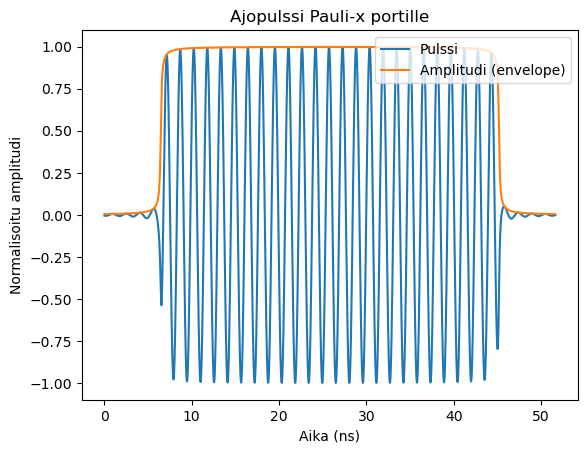

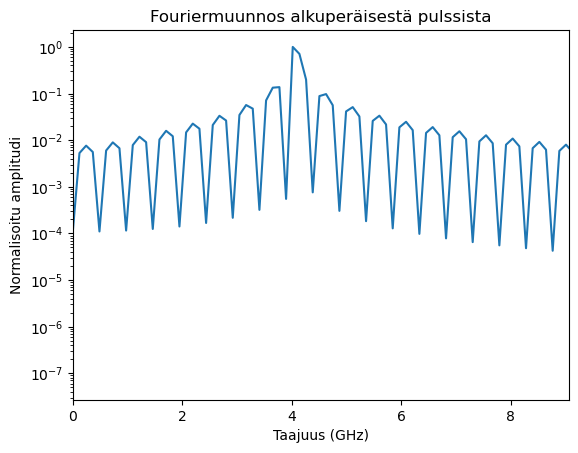

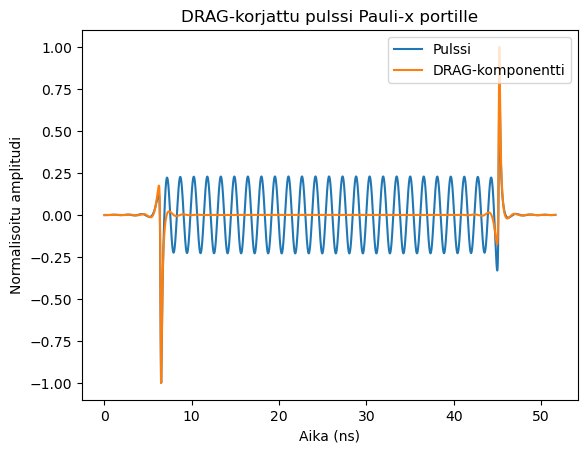

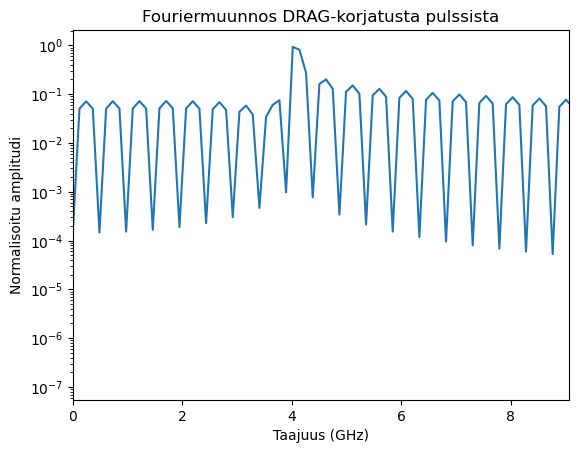

In [112]:
a=10 #Reunan pyöristyminen, suurempi=terävämpi reuna

#Kanttipulssi muodostettuna kahdesta vastakkaisesta arkustangenttifunktiosta symmetrisesti pulssin keskipisteen suhteen
square_pulse = Pulse(f_d,f_ef,[arctan(edge_offset*dt,a),arctan_opp((N_start-edge_offset)*dt,a)],[N_start,N_end],time_unit=dt)

fig1=plt.figure()
plt.plot(square_pulse.time_vals,square_pulse.raw)
plt.plot(square_pulse.time_vals,square_pulse.envelope)
plt.xlabel("Aika (ns)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Ajopulssi Pauli-x portille")
plt.legend(["Pulssi","Amplitudi (envelope)"], loc = 'upper right')
plt.show()

fig2=plt.figure()
plt.semilogy(square_pulse.freqs*2*np.pi, np.abs(square_pulse.fourier)/np.max(np.abs(square_pulse.fourier)))
plt.xlim([0,f_d(0)+5])
plt.xlabel("Taajuus (GHz)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Fouriermuunnos alkuperäisestä pulssista")
plt.show()

fig3=plt.figure()
plt.plot(square_pulse.time_vals,square_pulse.drag_pulse/np.max(np.abs(square_pulse.drag_pulse)))
plt.plot(square_pulse.time_vals,square_pulse.drag_component/np.max(np.abs(square_pulse.drag_component)))
plt.legend(["Pulssi","DRAG-komponentti"],loc = 'upper right')
plt.xlabel("Aika (ns)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("DRAG-korjattu pulssi Pauli-x portille")
plt.show()

fig4=plt.figure()
plt.semilogy(square_pulse.freqs*2*np.pi, np.abs(square_pulse.drag_fourier)/np.max(np.abs(square_pulse.fourier)))
plt.xlim([0,f_d(0)+5])
plt.xlabel("Taajuus (GHz)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Fouriermuunnos DRAG-korjatusta pulssista")
plt.show()

In [113]:
dim = 7

evolution_eigenbasis=time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [114]:
#Simulaatio ominaiskannassa

psi_eig = np.zeros((N, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi_eig[0,0] = 1

for i in range(1, N): #Aikakehitys
    psi_eig[i] = evolution_eigenbasis.U(A*square_pulse.raw[i], dt) @ psi_eig[i-1]

E-tason suurin todennäköisyys
0.972650979542661


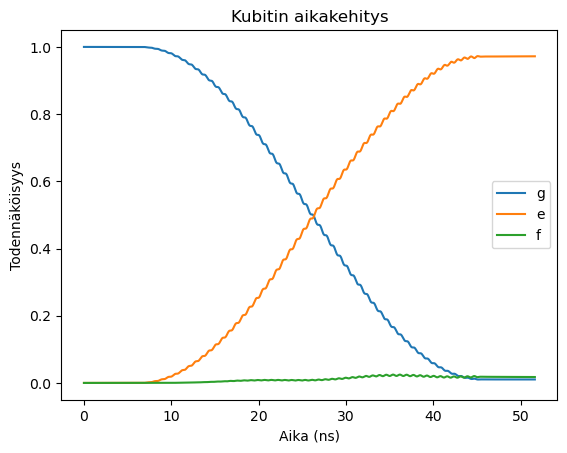

In [115]:
prob_g = np.abs(psi_eig[:, 0])**2
prob_e = np.abs(psi_eig[:, 1])**2
prob_f = np.abs(psi_eig[:, 2])**2

plt.plot(square_pulse.time_vals,prob_g)
plt.plot(square_pulse.time_vals,prob_e)
plt.plot(square_pulse.time_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Kubitin aikakehitys")
plt.legend(['g','e','f'])

print("E-tason suurin todennäköisyys")
print(np.max(prob_e))

In [116]:
print("Tasojen lopulliset todennäköisyydet (g,e,f):")
print(prob_g[-1])
print(prob_e[-1])
print(prob_f[-1])
print("")
print("e-tason suurin todennäköisyys:")
print(np.max(prob_e))

Tasojen lopulliset todennäköisyydet (g,e,f):
0.010278318672268435
0.9720877072518382
0.01758104560951796

e-tason suurin todennäköisyys:
0.972650979542661


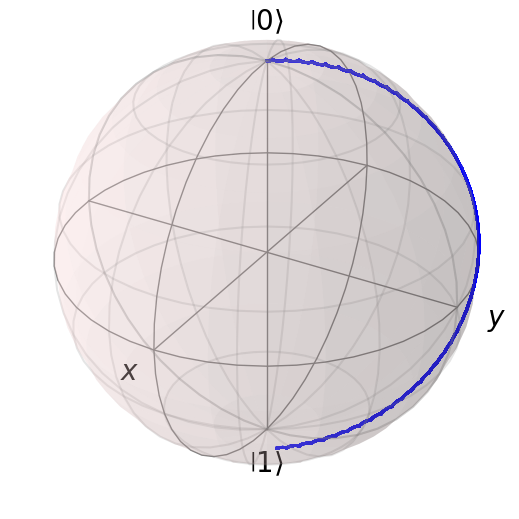

In [117]:
#Esitys Blochin-pallolla

theta_vals=2*np.arccos(np.abs(psi_eig[:,0])) #Napakulman arvot
phi_vals=np.angle(psi_eig[:,1])-np.angle(psi_eig[:,0])+square_pulse.time_vals*qubit.frequency #Vaakakulman arvot

xpts=np.sin(theta_vals)*np.cos(phi_vals)
ypts=np.sin(theta_vals)*np.sin(phi_vals)
zpts=np.cos(theta_vals)

b=qt.Bloch()
b.point_size = [1,1,1,1]
b.add_points([xpts,ypts,zpts])
b.show()

### Simulaatio DRAG-pulssille

In [118]:
psi_eig = np.zeros((N, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi_eig[0,0] = 1

for i in range(1, N): #Aikakehitys
    psi_eig[i] = evolution_eigenbasis.U(A*square_pulse.drag_pulse[i], dt) @ psi_eig[i-1]

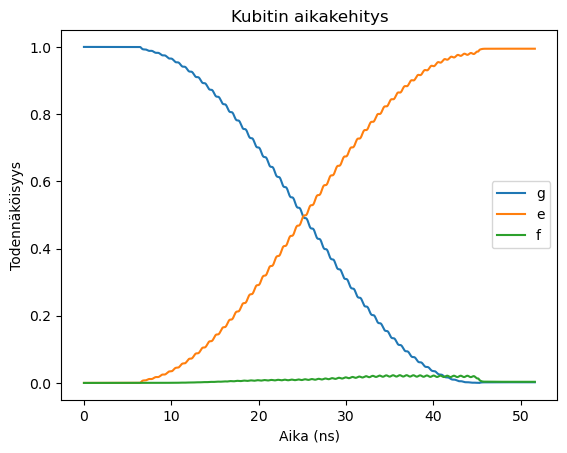

In [119]:
prob_g = np.abs(psi_eig[:, 0])**2
prob_e = np.abs(psi_eig[:, 1])**2
prob_f = np.abs(psi_eig[:, 2])**2

plt.plot(square_pulse.time_vals,prob_g)
plt.plot(square_pulse.time_vals,prob_e)
plt.plot(square_pulse.time_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Kubitin aikakehitys")
plt.legend(['g','e','f'])

In [120]:
print("Tasojen lopulliset todennäköisyydet (g,e,f):")
print(prob_g[-1])
print(prob_e[-1])
print(prob_f[-1])
print("")
print("e-tason suurin todennäköisyys:")
print(np.max(prob_e))

Tasojen lopulliset todennäköisyydet (g,e,f):
0.0019813903849751815
0.9946788269890138
0.00332143689809579

e-tason suurin todennäköisyys:
0.9947038185185394


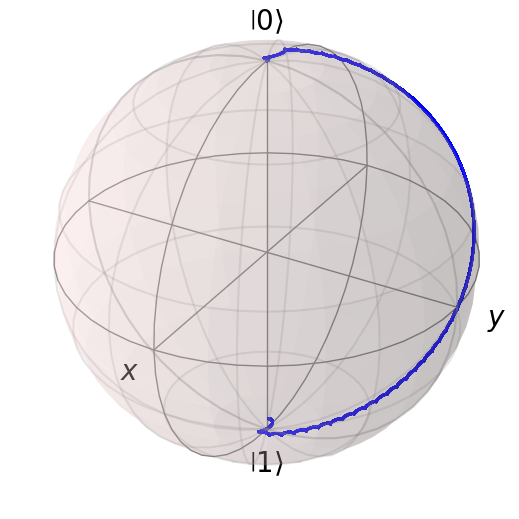

In [121]:
#Esitys Blochin-pallolla

theta_vals=2*np.arccos(np.abs(psi_eig[:,0])) #Napakulman arvot
phi_vals=np.angle(psi_eig[:,1])-np.angle(psi_eig[:,0])+square_pulse.time_vals*qubit.frequency #Vaakakulman arvot

xpts=np.sin(theta_vals)*np.cos(phi_vals)
ypts=np.sin(theta_vals)*np.sin(phi_vals)
zpts=np.cos(theta_vals)

b=qt.Bloch()
b.point_size = [1,1,1,1]
b.add_points([xpts,ypts,zpts])
b.show()